In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
!find /content/drive/MyDrive -name "03EDA.ipynb"

/content/drive/MyDrive/03EDA.ipynb


In [74]:
from google.colab import userdata, drive
import os

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Cấu hình thông tin (Lấy token từ Secrets)
GIT_TOKEN = userdata.get("My_Token")
GIT_USERNAME = "Nvnk26"
GIT_EMAIL = "tetraman261@gmail.com"
REPO_OWNER = "nhnminh1409"
GIT_REPO = "instacart-market-basket-analysis"

# Đường dẫn file nguồn (Hãy đảm bảo đường dẫn này đúng)
SOURCE_PATH = "/content/drive/MyDrive/03EDA.ipynb"

# 3. Thiết lập Repo
%cd /content/
PUSH_URL = f"https://{GIT_TOKEN}@://github.com{REPO_OWNER}/{GIT_REPO}.git"

if not os.path.exists(GIT_REPO):
    !git clone {PUSH_URL}
else:
    print("Repo đã tồn tại!")
https://github.com/nhnminh1409/instacart-market-basket-analysis/tree/main/notebooks
%cd {GIT_REPO}
!git config --global user.email "{GIT_EMAIL}"
!git config --global user.name "{GIT_USERNAME}"
!git config --global commit.gpgsign false

!git fetch origin
!git reset --hard origin/main

# 4. COPY FILE VÀ PUSH SẠCH
# Chắc chắn file nguồn không còn chứa mã ghp_ trực tiếp bên trong
!cp "{SOURCE_PATH}" .

!git add .
!git commit -m "Upload clean notebook from Colab"
!git push origin main --force

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
Repo đã tồn tại!
/content/instacart-market-basket-analysis
HEAD is now at 0968812 Delete notebooks/03_EDA_and_Features.ipynb
[main 4457eba] Upload clean notebook from Colab
 1 file changed, 1 insertion(+)
 create mode 100644 03EDA.ipynb
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 337.95 KiB | 9.13 MiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/nhnminh1409/instacart-market-basket-analysis.git
   0968812..4457eba  main -> main


## Product & User Behavior Analysis

This section builds product-level and user–product features to analyze purchasing behavior, focusing on popularity, reorder patterns, and user preferences.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


# Mount Drive to access the shared folder
drive.mount('/content/drive')


# Path to the cleaned data folder
DATA_PATH = '/content/drive/MyDrive/Instacart_Project/'


# Read Parquet file
df_prior = pd.read_parquet(DATA_PATH + 'prior_data_cleaned.parquet')


print("Data loaded successfully!")

Mounted at /content/drive
Data loaded successfully!


### 1. Product Reorder Rate

We calculate the reorder rate for each product to measure how frequently it is purchased again. This helps identify products with strong customer loyalty.

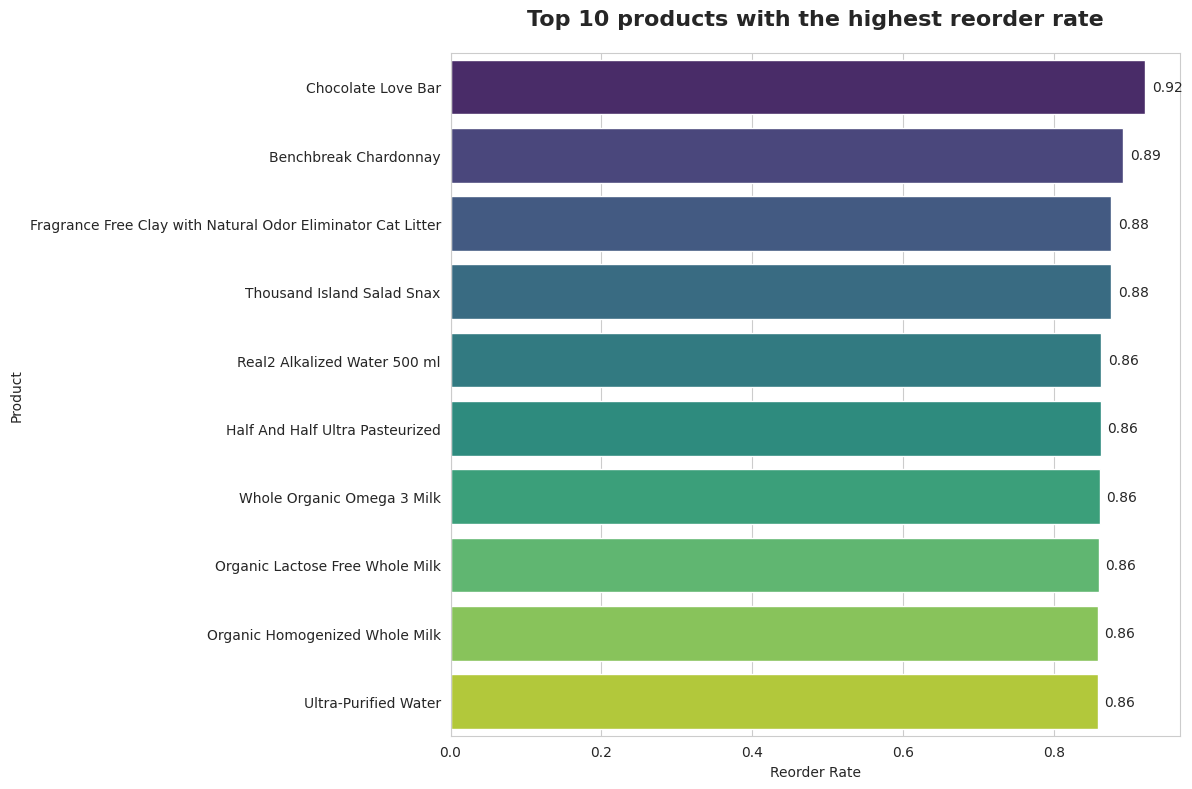

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load product information (product_id and product_name)
df_products = pd.read_csv(DATA_PATH + 'products.csv')

# Group by product_id and compute:
# - sum: total number of times the product was reordered
# - count: total number of times the product was purchased
# - mean: reorder rate (average of reordered column)
product_stats = df_prior.groupby('product_id').agg({
    'reordered': ['sum', 'count', 'mean']
})

# Rename columns for better readability
product_stats.columns = ['total_reorders', 'total_products', 'reorder_rate']

# Reset index to turn product_id back into a normal column
product_stats = product_stats.reset_index()

# Merge with product names to make the data more interpretable
product_features_final = product_stats.merge(
    df_products[['product_id', 'product_name']],  # select only necessary columns
    on='product_id',  # join on product_id
    how='left'  # keep all rows from product_stats
)

# Reorder columns for a clean structure
product_features_final = product_features_final[[
    'product_id',
    'product_name',
    'total_reorders',
    'total_products',
    'reorder_rate'
]]


# Filter products with enough observations (more than 100 purchases)
# Then:
# - sort by reorder_rate descending
# - take top 10 products
top_reorder = product_features_final[
    product_features_final['total_products'] > 100
].sort_values(by='reorder_rate', ascending=False).head(10)

# Set plot style
sns.set_style("whitegrid")

# Create figure with larger size
plt.figure(figsize=(12, 8))

# Create horizontal bar chart:
# - x-axis: reorder rate
# - y-axis: product names
ax = sns.barplot(
    x='reorder_rate',
    y='product_name',
    data=top_reorder,
    hue='product_name',   # assign different colors to each product
    palette='viridis',    # color palette
    legend=False          # no legend needed
)

# Add title and axis labels
ax.set_title('Top 10 products with the highest reorder rate', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Reorder Rate')
ax.set_ylabel('Product')

# Display values on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
pip install squarify

### 2. First-in-Basket Products

We identify products that are most frequently added first to the cart. These items often represent essential or habitual purchases.

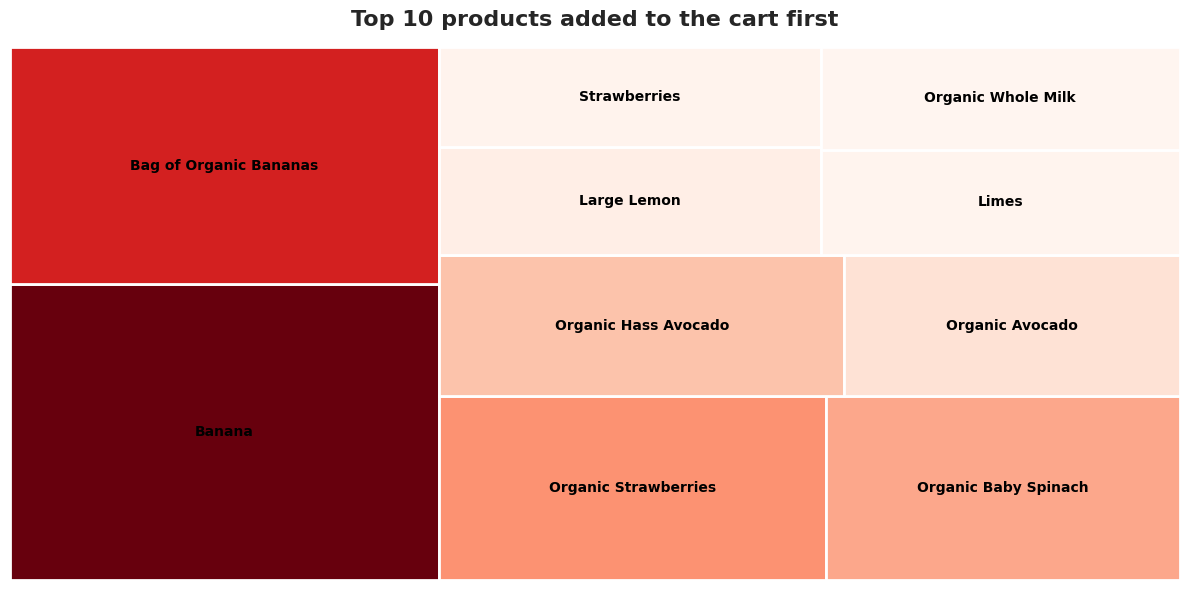

In [ ]:
import squarify
import matplotlib.colors as mcolors

# 1. Load product catalog (CSV) and transaction data (Parquet)
df_products = pd.read_csv(DATA_PATH + 'products.csv')

# 2. Compute the "First Add-to-Cart Product" feature

# Step A: Count total number of purchases for each product from df_prior
total_counts = df_prior.groupby('product_id').size().reset_index(name='total_purchases')

# Step B: Filter rows where the product was added first in the cart (add_to_cart_order == 1)
first_orders = df_prior[df_prior['add_to_cart_order'] == 1]
first_counts = first_orders.groupby('product_id').size().reset_index(name='total_first_orders')

# Step C: Merge counts and calculate the ratio
first_to_cart_df = total_counts.merge(first_counts, on='product_id', how='left')
first_to_cart_df['total_first_orders'] = first_to_cart_df['total_first_orders'].fillna(0)

# Calculate first-to-cart rate = first orders / total purchases
first_to_cart_df['first_to_cart_rate'] = (
    first_to_cart_df['total_first_orders'] / first_to_cart_df['total_purchases']
).round(4)

# Step D: Merge with df_products to get product names
final_df = first_to_cart_df.merge(
    df_products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

# Reorder columns for clarity
final_df = final_df[
    ['product_id', 'product_name', 'total_first_orders', 'total_purchases', 'first_to_cart_rate']
]

# --- DRAW TREEMAP ---

# Select top 10 most purchased products
top_df = final_df.sort_values(by='total_purchases', ascending=False).head(10)

# Normalize colors (darker green = higher value)
norm = mcolors.Normalize(
    vmin=top_df['total_purchases'].min(),
    vmax=top_df['total_purchases'].max()
)

colors = plt.cm.Reds(norm(top_df['total_purchases']))

plt.figure(figsize=(12, 6))

# Create treemap
squarify.plot(
    sizes=top_df['total_purchases'],   # rectangle sizes based on total purchases
    label=top_df['product_name'],      # labels are product names
    color=colors,
    alpha=1,
    edgecolor='white',   # white borders between rectangles
    linewidth=2,
    text_kwargs={
        'fontsize': 10,
        'color': 'black',
        'weight': 'bold',
    }
)

plt.axis('off')  # remove axes
plt.title(
    'Top 10 products added to the cart first',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()

### 3. User–Product Interaction Features

We construct interaction features between users and products, including:

- Purchase frequency: number of times a user bought a product  
- Recency: the most recent order containing the product  
- Reorder ratio: how often the product is repurchased relative to other items  

These features capture user preference and product importance at an individual level.

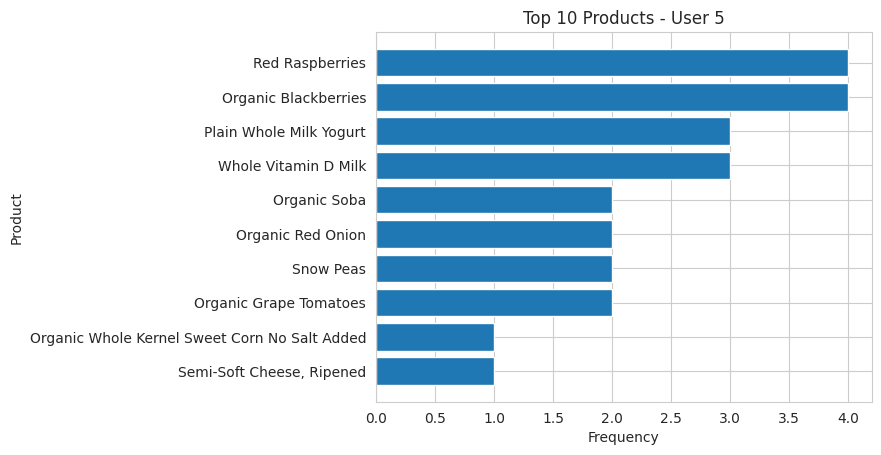


--- TOP PRODUCTS BY RECENCY  ---
                                 product_name  last_order_number
Organic Whole Kernel Sweet Corn No Salt Added                  4
              Large Organic Omega3 Brown Eggs                  4
                         Whole Vitamin D Milk                  4
                       Organic Grape Tomatoes                  4
                         Uncured Genoa Salami                  4
                         Organic Blackberries                  4
                      Plain Whole Milk Yogurt                  4
                    Semi-Soft Cheese, Ripened                  4
                                 Organic Soba                  4
                                    Snow Peas                  4

--- TOP PRODUCTS BY PREFERENCE  ---
                                 product_name  times_bought  purchase_ratio
                              Red Raspberries             4        0.108108
                         Organic Blackberries             4   

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 1. USER - PRODUCT FEATURES
# ================================

user_product = df_prior.groupby(['user_id', 'product_id']).agg(
    times_bought=('order_number', 'count'),        # Frequency
    last_order_number=('order_number', 'max')      # Recency
).reset_index()

# ================================
# 2. USER LEVEL
# ================================

user_total_items = df_prior.groupby('user_id').size().reset_index(name='user_total_items')
user_total_orders = df_prior.groupby('user_id')['order_number'].max().reset_index(name='user_total_orders')

user_product = user_product.merge(user_total_items, on='user_id')
user_product = user_product.merge(user_total_orders, on='user_id')

# ================================
# 3. METRICS
# ================================

# Preference
user_product['purchase_ratio'] = (
    user_product['times_bought'] / user_product['user_total_items']
)

# ================================
# 4. ADD PRODUCT NAME
# ================================

df_products = pd.read_csv(DATA_PATH + 'products.csv')

final_df = user_product.merge(
    df_products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

# ================================
# 5. Choose user
# ================================

user_id = 5
user_data = final_df[final_df['user_id'] == user_id]

# ================================
# 6. Graph 1: TOP PRODUCTS
# ================================

top_products = user_data.sort_values(
    'times_bought', ascending=False
).head(10)

plt.figure()
plt.barh(top_products['product_name'], top_products['times_bought'])
plt.title(f'Top 10 Products - User {user_id}')
plt.xlabel('Frequency')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.show()

# ================================
# 8. Board 2: RECENCY (Last bought)
# ================================

recency_table = user_data.sort_values(
    by='last_order_number', ascending=False
)[[
    'product_name',
    'last_order_number'
]].head(10)

print("\n--- TOP PRODUCTS BY RECENCY  ---")
print(recency_table.to_string(index=False))


# ================================
# 9. Board 3 : PREFERENCE (Percentage)
# ================================

preference_table = user_data.sort_values(
    by='purchase_ratio', ascending=False
)[[
    'product_name',
    'times_bought',
    'purchase_ratio'
]].head(10)

print("\n--- TOP PRODUCTS BY PREFERENCE  ---")
print(preference_table.to_string(index=False))


### 4. Exploratory Data Analysis

We visualize product and aisle popularity to better understand overall purchasing trends:

- Top 10 most popular products  
- Top 10 most popular aisles  


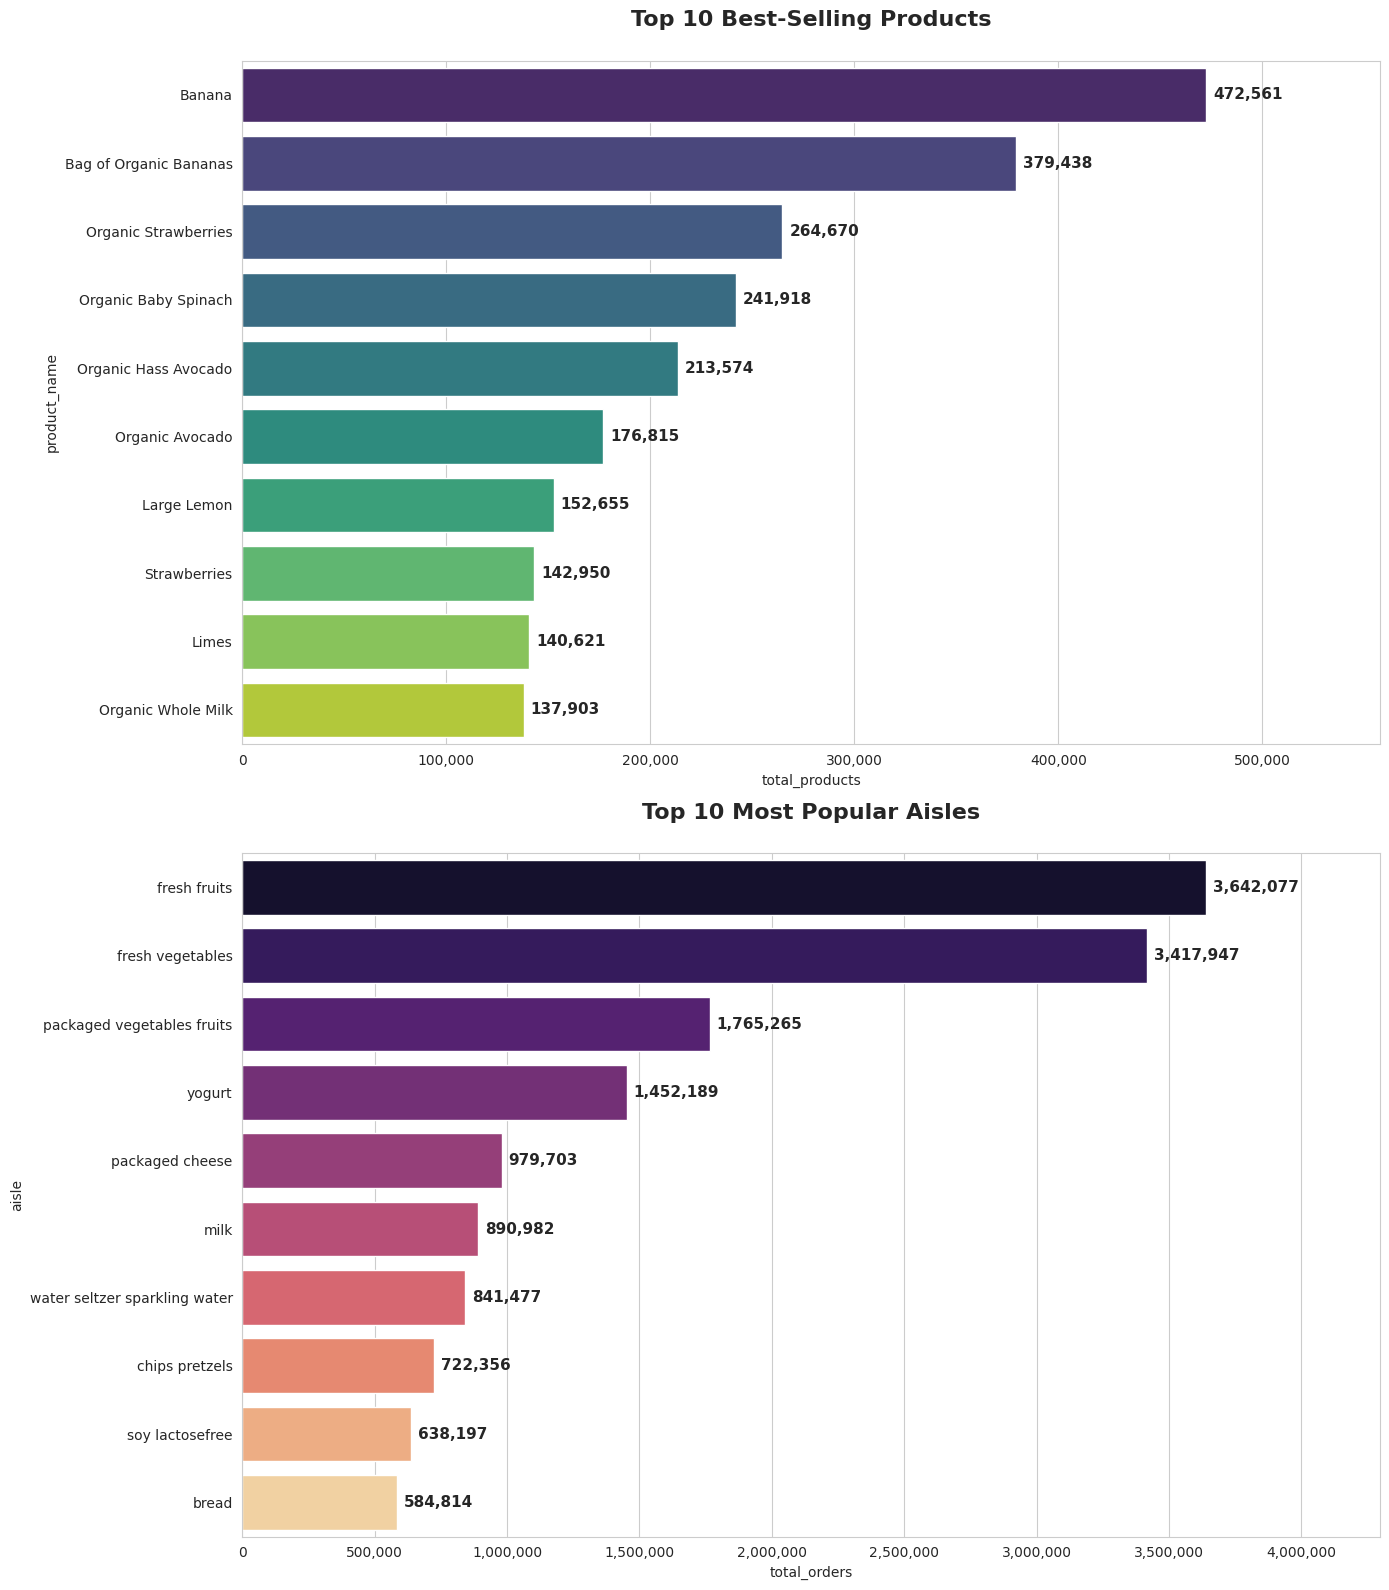

In [ ]:
import matplotlib.ticker as ticker
df_aisles = pd.read_csv(DATA_PATH + 'aisles.csv')
# --- 1. DATA PROCESSING ---

# Count how many times each product appears (i.e., total purchases per product)
product_stats = df_prior.groupby('product_id').size().reset_index(name='total_products')

# Merge with product names to make the results readable
product_features_final = product_stats.merge(
    df_products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

# Select top 10 most purchased products
top_products = product_features_final.sort_values(
    by='total_products',
    ascending=False
).head(10)


# Merge df_prior with product aisle information
# This allows us to analyze purchases at the aisle (category) level
df_merged_aisle = df_prior[['product_id']].merge(
    df_products[['product_id', 'aisle_id']],
    on='product_id',
    how='left'
)

# Count total number of orders per aisle
aisle_stats = df_merged_aisle.groupby('aisle_id').size().reset_index(name='total_orders')

# Merge with aisle names for readability
aisle_final = aisle_stats.merge(df_aisles, on='aisle_id', how='left')

# Select top 10 most popular aisles
top_aisles = aisle_final.sort_values(
    by='total_orders',
    ascending=False
).head(10)


# --- 2. VISUALIZATION ---

# Set plot style
sns.set_style("whitegrid")

# Create a figure with 2 subplots (vertical layout)
fig, ax = plt.subplots(2, 1, figsize=(14, 16))


# --- CHART 1: Top Products ---
sns.barplot(
    x='total_products',
    y='product_name',
    data=top_products,
    ax=ax[0],
    hue='product_name',   # each product gets a different color
    palette='viridis',
    legend=False
)

# Set title
ax[0].set_title('Top 10 Best-Selling Products', fontsize=16, fontweight='bold', pad=25)

# Format x-axis numbers with commas (e.g., 10000 -> 10,000)
ax[0].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: format(int(x), ','))
)

# Add value labels to ALL bars (important fix)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='{:,.0f}', padding=5, fontsize=11, fontweight='bold')


# --- CHART 2: Top Aisles ---
sns.barplot(
    x='total_orders',
    y='aisle',
    data=top_aisles,
    ax=ax[1],
    hue='aisle',   # each aisle gets a different color
    palette='magma',
    legend=False
)

# Set title
ax[1].set_title('Top 10 Most Popular Aisles', fontsize=16, fontweight='bold', pad=25)

# Format x-axis numbers with commas
ax[1].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: format(int(x), ','))
)

# Add value labels to ALL bars (important fix)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='{:,.0f}', padding=5, fontsize=11, fontweight='bold')


# Expand x-axis limits slightly so labels are not cut off
ax[0].set_xlim(right=top_products['total_products'].max() * 1.18)
ax[1].set_xlim(right=top_aisles['total_orders'].max() * 1.18)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

###5. We analyze how different departments contribute to total order volume using Pareto analysis.

- Departments are ranked by total number of orders
- Cumulative percentage is calculated to show contribution concentration
- Helps identify whether a small number of departments drive most sales

This is useful for prioritizing business focus and resource allocation.

/tmp/ipykernel_497/3591031074.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


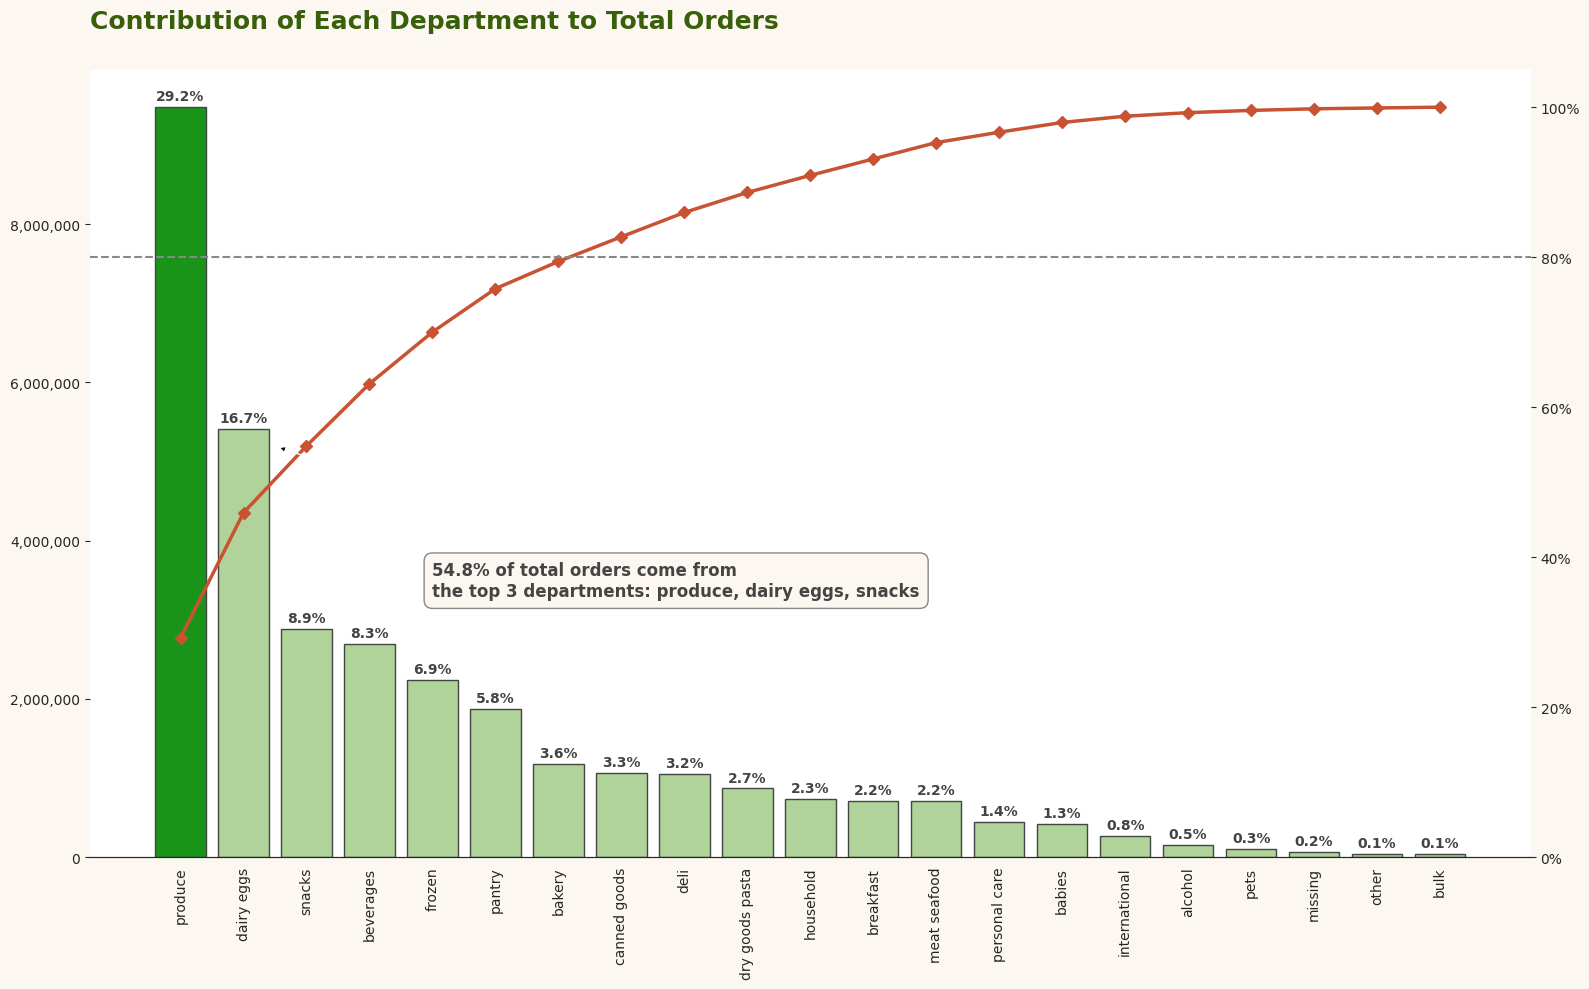

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# =========================================================
# 1. DATA PREPARATION
# =========================================================
# We assume df_final_dept has been created in previous steps.
# It contains the total number of orders per department.

df_pareto = df_final_dept.sort_values(by='total_orders', ascending=False).reset_index(drop=True)

# Calculate total number of orders across all departments
total_all_orders = df_pareto['total_orders'].sum()

# Compute cumulative percentage contribution (Pareto cumulative curve)
df_pareto['cumulative_perc'] = 100 * df_pareto['total_orders'].cumsum() / total_all_orders

# Compute individual percentage contribution of each department
df_pareto['individual_perc'] = 100 * df_pareto['total_orders'] / total_all_orders


# =========================================================
# 2. PLOT CONFIGURATION
# =========================================================
sns.set_style("white")
fig, ax1 = plt.subplots(figsize=(16, 10), facecolor='#FCF8F1')

# =========================================================
# 3. PRIMARY AXIS: BAR CHART (ORDER VOLUME BY DEPARTMENT)
# =========================================================
bars = sns.barplot(
    x='department',
    y='total_orders',
    data=df_pareto,
    ax=ax1,
    color='#AEDD8F',
    edgecolor='#444'
)

# Chart title
ax1.set_title(
    'Contribution of Each Department to Total Orders',
    fontsize=18,
    fontweight='bold',
    pad=30,
    color='#3A5F0B',
    loc='left'
)

# Highlight the first (largest) department bar
ax1.patches[0].set_facecolor('#199419')

# Add percentage labels on top of each bar
for i, bar in enumerate(ax1.patches):
    height = bar.get_height()
    perc = df_pareto.loc[i, 'individual_perc']
    ax1.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 50000,
        f'{perc:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight='bold',
        color='#444'
    )

# Format Y-axis with thousand separators
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Rotate X labels for better readability
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

ax1.set_ylabel('')
ax1.set_xlabel('')


# =========================================================
# 4. SECONDARY AXIS: CUMULATIVE PARETO LINE
# =========================================================
ax2 = ax1.twinx()

# Plot cumulative percentage line
ax2.plot(
    df_pareto['department'],
    df_pareto['cumulative_perc'],
    color='#C85232',
    marker='D',
    markersize=6,
    linewidth=2.5
)

ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter())

# 80% reference line (Pareto principle threshold)
ax2.axhline(80, color='#888', linestyle='--', linewidth=1.5)


# =========================================================
# 5. INTERPRETATION (PARETO INSIGHT)
# =========================================================
# This section highlights key business insight from the Pareto analysis.
# It shows how many departments contribute to a large portion of total orders.

top_3_perc = df_pareto['cumulative_perc'].iloc[2].round(1)
dept_names = ", ".join(df_pareto['department'].iloc[:3].tolist())

annotation_text = (
    f"{top_3_perc}% of total orders come from\n"
    f"the top 3 departments: {dept_names}"
)

ax2.annotate(
    annotation_text,
    xy=(1.5, top_3_perc),
    xytext=(4, top_3_perc - 20),
    arrowprops=dict(facecolor='black', arrowstyle='-|>'),
    fontsize=12,
    fontweight='bold',
    color='#444',
    bbox=dict(boxstyle="round,pad=0.5", fc="#FCF8F1", ec="#888", lw=1)
)


# =========================================================
# 6. FINAL TOUCHES
# =========================================================
sns.despine(ax=ax1, left=True, right=True)
sns.despine(ax=ax2, left=True, right=True)
plt.tight_layout()
plt.show()

###6. We construct a co-occurrence matrix to analyze product pairing behavior in customer baskets.

- Each cell shows how often two products are purchased together in the same order
- Captures natural associations between products
- Helps identify frequently bundled items

This is useful for recommendation systems and cross-selling strategies.

In [ ]:
# =========================================================
# 1. DEFINE TARGET PRODUCTS (ROW & COLUMN SET)
# =========================================================
# We manually select a subset of products to analyze
# co-purchase relationships between them.

row_names = [
    'Organic Hass Avocado', 'Organic Strawberries', 'Organic Yellow Onion',
    'Organic Zucchini', 'Strawberries'
]

col_names = [
    'Bag of Organic Bananas', 'Banana', 'Large Lemon',
    'Limes', 'Organic Baby Spinach'
]


# =========================================================
# 2. MAP PRODUCT NAMES TO PRODUCT IDs
# =========================================================
# Convert product names into product_id for faster filtering

product_id_map = products.set_index('product_name')['product_id'].to_dict()

row_ids = [product_id_map[name] for name in row_names]
col_ids = [product_id_map[name] for name in col_names]


print("Computing co-purchase matrix... (this may take 30–90 seconds)")


# =========================================================
# 3. BUILD CO-OCCURRENCE MATRIX
# =========================================================
# This matrix counts how often two products are bought in the same order

co_occ = pd.DataFrame(0, index=row_names, columns=col_names)

for i, row_prod in enumerate(row_names):
    row_pid = row_ids[i]

    # Find all orders containing the row product
    orders_with_row = prior[prior['product_id'] == row_pid]['order_id'].unique()

    for j, col_prod in enumerate(col_names):
        col_pid = col_ids[j]

        if row_pid == col_pid:
            # If same product: count total occurrences
            count = len(orders_with_row)
        else:
            # Otherwise: count overlapping orders between two products
            orders_with_col = prior[prior['product_id'] == col_pid]['order_id'].unique()
            count = len(set(orders_with_row) & set(orders_with_col))

        co_occ.loc[row_prod, col_prod] = count


# =========================================================
# 4. VISUALIZATION FUNCTION (HEATMAP-STYLE TABLE)
# =========================================================
# This function applies styling to highlight co-purchase intensity

def style_frequently_bought(df):
    return (df.style
            .format("{:,}")
            .background_gradient(cmap='Greens', axis=None)
            .set_caption("Frequently Co-Purchased Products Matrix")
            .set_table_styles([
                {'selector': 'caption',
                 'props': [('font-size', '18px'),
                           ('font-weight', 'bold'),
                           ('color', '#1b5e20'),
                           ('padding', '12px 0 8px 0')]},
                {'selector': 'th.col_heading',
                 'props': [('background-color', '#43a047'),
                           ('color', 'white'),
                           ('font-weight', 'bold'),
                           ('padding', '10px 6px')]},
                {'selector': 'th.row_heading',
                 'props': [('background-color', '#e8f5e9'),
                           ('font-weight', 'bold'),
                           ('text-align', 'left'),
                           ('padding', '10px 12px')]},
                {'selector': 'td',
                 'props': [('text-align', 'center'),
                           ('padding', '9px 6px')]}
            ]))

styled = style_frequently_bought(co_occ)
styled

Computing co-purchase matrix... (this may take 30–90 seconds)


,Bag of Organic Bananas,Banana,Large Lemon,Limes,Organic Baby Spinach
Organic Hass Avocado,"62,341","31,222","15,005","20,030","34,901"
Organic Strawberries,"61,628","56,156","16,305","18,999","38,134"
Organic Yellow Onion,"24,574","16,695","11,045","12,756","19,707"
Organic Zucchini,"22,632","19,318","11,303","10,182","20,415"
Strawberries,"17,611","41,232","11,393","7,994","13,751"
